### 1- Installation
Installation des principales bibliothèques de notre projet :
- Ultralytics → YOLO
- OpenCV → traitement et visualisation des images
- Matplotlib → graphiques
- Pandas → analyse des données
- PyYAML → lecture de data.yaml
- Pillow → manipulation d'images
- NumPy → calcul numérique
- Seaborn → visualisations statistiques
- Scikit-learn → certaines métriques d'évaluation

In [1]:
%pip install ultralytics opencv-python matplotlib pandas pyyaml pillow numpy seaborn scikit-learn

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.4 MB 1.3 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.4 MB 1.0 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.4 MB 1.0 MB/s eta 0:00:01
   ----------------------------- ---------- 1.0/1.4 MB 1.0 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.4 MB 976.5 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 917.5 kB/s  0:00:01
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 542.5 kB/s eta 0:01:21
    --------------------------------------- 0.8

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2- importation des bibliotheques

In [2]:
from pathlib import Path
import random
import yaml
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from ultralytics import YOLO

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


### 3-Configuration des chemins

In [3]:

# Racine du projet
PROJECT_ROOT = Path.cwd().parent

# Dossier principal du dataset
DATASET_ROOT = PROJECT_ROOT / "data" / "fieldplant"

# Dossiers des différents ensembles
RAW_DIR = DATASET_ROOT / "raw"
TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

# Fichier de configuration YOLO
DATA_YAML = PROJECT_ROOT / "configs" / "data.yaml"

# Dossiers images et labels
TRAIN_IMAGES = TRAIN_DIR / "images"
TRAIN_LABELS = TRAIN_DIR / "labels"

VALID_IMAGES = VALID_DIR / "images"
VALID_LABELS = VALID_DIR / "labels"

TEST_IMAGES = TEST_DIR / "images"
TEST_LABELS = TEST_DIR / "labels"


# ============================================================
# AFFICHAGE
# ============================================================

print("Racine du projet :")
print(PROJECT_ROOT)

print("\nDataset :")
print(DATASET_ROOT)

print("\nFichier data.yaml :")
print(DATA_YAML)

print("\nDossiers :")
print(f"Train      : {TRAIN_DIR}")
print(f"Validation : {VALID_DIR}")
print(f"Test       : {TEST_DIR}")

Racine du projet :
d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires

Dataset :
d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant

Fichier data.yaml :
d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\configs\data.yaml

Dossiers :
Train      : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant\train
Validation : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant\valid
Test       : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant\test


### 4- lecture et ferification de data.yaml

In [4]:
# ============================================================
# CELLULE 4 — LECTURE DU DATA.YAML
# ============================================================

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("Configuration YOLO chargée avec succès !")
print("=" * 60)

print("Nombre de classes :", data_config["nc"])
print("Train            :", data_config["train"])
print("Validation       :", data_config["val"])
print("Test             :", data_config["test"])

print("\nNombre de noms de classes :", len(data_config["names"]))

print("\n✓ Vérification :")

assert data_config["nc"] == 27
assert len(data_config["names"]) == 27

print("✓ 27 classes déclarées")
print("✓ 27 noms de classes présents")

Configuration YOLO chargée avec succès !
Nombre de classes : 27
Train            : train/images
Validation       : valid/images
Test             : test/images

Nombre de noms de classes : 27

✓ Vérification :
✓ 27 classes déclarées
✓ 27 noms de classes présents


### 5- affichage des 27 classes

In [5]:
# ============================================================
# CELLULE 5 — AFFICHAGE DES 27 CLASSES
# ============================================================

# Récupération des noms de classes
class_names = data_config["names"]

# Conversion du dictionnaire en tableau
classes_df = pd.DataFrame(
    [
        {"ID": class_id, "Nom de la classe": class_name}
        for class_id, class_name in class_names.items()
    ]
)

# Affichage
print("LISTE DES 27 CLASSES DU DATASET FIELDPLANT")
print("=" * 60)

display(classes_df)

print("\nNombre total de classes :", len(classes_df))

LISTE DES 27 CLASSES DU DATASET FIELDPLANT


,ID,Nom de la classe
0,0,Flétrissement bactérien du manioc
1,1,Tache brune des feuilles du manioc
2,2,Manioc sain
3,3,Mosaïque du manioc
4,4,Pourriture des racines du manioc
5,5,Taches brunes du maïs
6,6,Charbon du maïs
7,7,Tache chlorotique des feuilles du maïs
8,8,Tache grise des feuilles du maïs
9,9,Maïs sain



Nombre total de classes : 27


In [6]:
# ============================================================
# CELLULE 6 — CORRESPONDANCE ANGLAIS → FRANÇAIS
# ============================================================
english_names = [
    "Cassava Bacterial Blight",
    "Cassava Brown Leaf Spot",
    "Cassava Healthy",
    "Cassava Mosaic",
    "Cassava Root Rot",
    "Corn Brown Spots",
    "Corn Charcoal",
    "Corn Chlorotic Leaf Spot",
    "Corn Gray leaf spot",
    "Corn Healthy",
    "Corn Insects Damages",
    "Corn Mildew",
    "Corn Purple Discoloration",
    "Corn Smut",
    "Corn Streak",
    "Corn Stripe",
    "Corn Violet Decoloration",
    "Corn Yellow Spots",
    "Corn Yellowing",
    "Corn leaf blight",
    "Corn rust leaf",
    "Tomato Brown Spots",
    "Tomato bacterial wilt",
    "Tomato blight leaf",
    "Tomato healthy",
    "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus"
]

french_names = list(data_config["names"].values())

translation_df = pd.DataFrame({
    "ID": range(27),
    "Nom anglais": english_names,
    "Nom français": french_names
})

display(translation_df)

print("\nNombre total de classes :", len(translation_df))

,ID,Nom anglais,Nom français
0,0,Cassava Bacterial Blight,Flétrissement bactérien du manioc
1,1,Cassava Brown Leaf Spot,Tache brune des feuilles du manioc
2,2,Cassava Healthy,Manioc sain
3,3,Cassava Mosaic,Mosaïque du manioc
4,4,Cassava Root Rot,Pourriture des racines du manioc
5,5,Corn Brown Spots,Taches brunes du maïs
6,6,Corn Charcoal,Charbon du maïs
7,7,Corn Chlorotic Leaf Spot,Tache chlorotique des feuilles du maïs
8,8,Corn Gray leaf spot,Tache grise des feuilles du maïs
9,9,Corn Healthy,Maïs sain



Nombre total de classes : 27


In [7]:
# ============================================================
# CELLULE 7 — VÉRIFICATION DU DATASET
# ============================================================

def verifier_dataset(images_dir, labels_dir):
    images = {
        p.stem for p in images_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    }

    labels = {
        p.stem for p in labels_dir.iterdir()
        if p.suffix.lower() == ".txt"
    }

    images_sans_label = images - labels
    labels_sans_image = labels - images

    lignes_invalides = 0
    classes_invalides = 0
    coordonnees_invalides = 0

    for label_file in labels_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                # Une annotation YOLO doit contenir :
                # class_id x_center y_center width height
                if len(parts) != 5:
                    lignes_invalides += 1
                    continue

                try:
                    class_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:])
                except ValueError:
                    lignes_invalides += 1
                    continue

                if not (0 <= class_id < 27):
                    classes_invalides += 1

                if not all(0 <= value <= 1 for value in [x, y, w, h]):
                    coordonnees_invalides += 1

    print("VÉRIFICATION DU DATASET")
    print("=" * 60)

    print(f"Nombre d'images              : {len(images)}")
    print(f"Nombre de labels             : {len(labels)}")
    print(f"Images sans annotation       : {len(images_sans_label)}")
    print(f"Annotations sans image       : {len(labels_sans_image)}")
    print(f"Lignes YOLO invalides        : {lignes_invalides}")
    print(f"Classes invalides            : {classes_invalides}")
    print(f"Coordonnées invalides        : {coordonnees_invalides}")

    print("\n" + "=" * 60)

    if (
        len(images_sans_label) == 0
        and len(labels_sans_image) == 0
        and lignes_invalides == 0
        and classes_invalides == 0
        and coordonnees_invalides == 0
    ):
        print("✓ DATASET VALIDE")
    else:
        print("⚠ Des problèmes ont été détectés")


# Vérification des trois ensembles
print("TRAIN")
verifier_dataset(TRAIN_IMAGES, TRAIN_LABELS)

print("\nVALIDATION")
verifier_dataset(VALID_IMAGES, VALID_LABELS)

print("\nTEST")
verifier_dataset(TEST_IMAGES, TEST_LABELS)

TRAIN
VÉRIFICATION DU DATASET
Nombre d'images              : 3609
Nombre de labels             : 3609
Images sans annotation       : 0
Annotations sans image       : 0
Lignes YOLO invalides        : 0
Classes invalides            : 0
Coordonnées invalides        : 0

✓ DATASET VALIDE

VALIDATION
VÉRIFICATION DU DATASET
Nombre d'images              : 773
Nombre de labels             : 773
Images sans annotation       : 0
Annotations sans image       : 0
Lignes YOLO invalides        : 0
Classes invalides            : 0
Coordonnées invalides        : 0

✓ DATASET VALIDE

TEST
VÉRIFICATION DU DATASET
Nombre d'images              : 774
Nombre de labels             : 774
Images sans annotation       : 0
Annotations sans image       : 0
Lignes YOLO invalides        : 0
Classes invalides            : 0
Coordonnées invalides        : 0

✓ DATASET VALIDE


In [8]:
# ============================================================
# CELLULE 8 — VÉRIFICATION DU SPLIT
# ============================================================

def obtenir_stems(dossier):
    return {
        p.stem
        for p in dossier.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    }


# Récupération des images
train_set = obtenir_stems(TRAIN_IMAGES)
valid_set = obtenir_stems(VALID_IMAGES)
test_set = obtenir_stems(TEST_IMAGES)


# Vérification des chevauchements
train_valid = train_set & valid_set
train_test = train_set & test_set
valid_test = valid_set & test_set

# Union de tous les ensembles
all_images = train_set | valid_set | test_set


print("VÉRIFICATION DU SPLIT DU DATASET")
print("=" * 60)

print(f"Train      : {len(train_set)} images")
print(f"Validation : {len(valid_set)} images")
print(f"Test       : {len(test_set)} images")

print("\nChevauchements :")
print(f"Train ∩ Validation : {len(train_valid)}")
print(f"Train ∩ Test       : {len(train_test)}")
print(f"Validation ∩ Test  : {len(valid_test)}")

print("\nNombre total d'images uniques :", len(all_images))

print("\n" + "=" * 60)

if len(train_valid) == 0 and len(train_test) == 0 and len(valid_test) == 0:
    print("✓ AUCUN CHEVAUCHEMENT DÉTECTÉ")
else:
    print("⚠ CHEVAUCHEMENT DÉTECTÉ")

if len(all_images) == 5156:
    print("✓ Les 5156 images sont présentes une seule fois.")
else:
    print(f"⚠ Nombre inattendu : {len(all_images)} images")

VÉRIFICATION DU SPLIT DU DATASET
Train      : 3609 images
Validation : 773 images
Test       : 774 images

Chevauchements :
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

Nombre total d'images uniques : 5156

✓ AUCUN CHEVAUCHEMENT DÉTECTÉ
✓ Les 5156 images sont présentes une seule fois.


RÉPARTITION DES CLASSES — ENSEMBLE D'ENTRAÎNEMENT


,ID,Classe,Nombre d'annotations
0,21,Taches brunes de la tomate,1367
1,3,Mosaïque du manioc,1338
2,19,Brûlure des feuilles du maïs,1145
3,18,Jaunissement du maïs,328
4,2,Manioc sain,284
5,23,Brûlure des feuilles de la tomate,273
6,24,Tomate saine,186
7,14,Stries du maïs,172
8,1,Tache brune des feuilles du manioc,154
9,5,Taches brunes du maïs,147


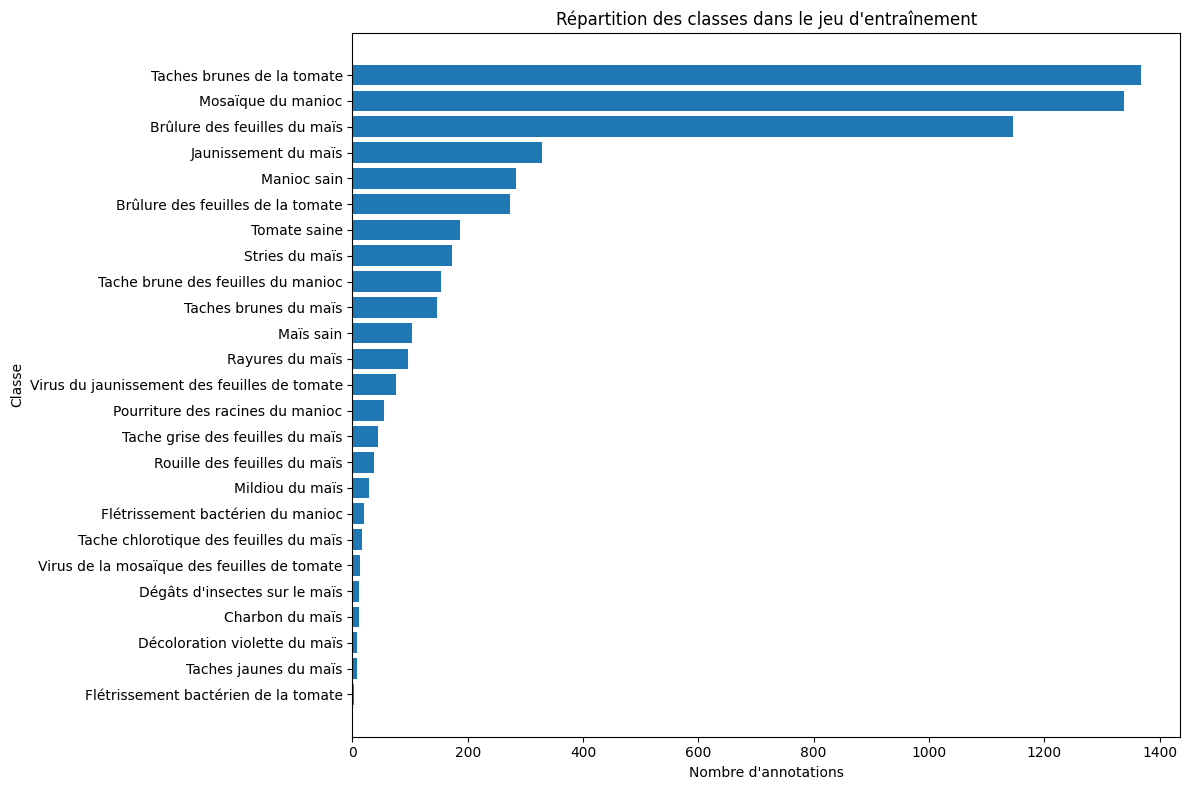

In [9]:
# ============================================================
# CELLULE 9 — ANALYSE DE LA RÉPARTITION DES CLASSES
# ============================================================

# Compter les annotations par classe
class_counts = {i: 0 for i in range(27)}

for label_file in TRAIN_LABELS.glob("*.txt"):
    with open(label_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) == 5:
                class_id = int(parts[0])

                if 0 <= class_id < 27:
                    class_counts[class_id] += 1


# Création du DataFrame
class_distribution = pd.DataFrame({
    "ID": list(class_counts.keys()),
    "Classe": [data_config["names"][i] for i in class_counts.keys()],
    "Nombre d'annotations": list(class_counts.values())
})

# Tri décroissant
class_distribution = class_distribution.sort_values(
    by="Nombre d'annotations",
    ascending=False
).reset_index(drop=True)


# Affichage du tableau
print("RÉPARTITION DES CLASSES — ENSEMBLE D'ENTRAÎNEMENT")
print("=" * 70)

display(class_distribution)


# ============================================================
# GRAPHIQUE
# ============================================================

plt.figure(figsize=(12, 8))

plt.barh(
    class_distribution["Classe"],
    class_distribution["Nombre d'annotations"]
)

plt.xlabel("Nombre d'annotations")
plt.ylabel("Classe")
plt.title("Répartition des classes dans le jeu d'entraînement")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

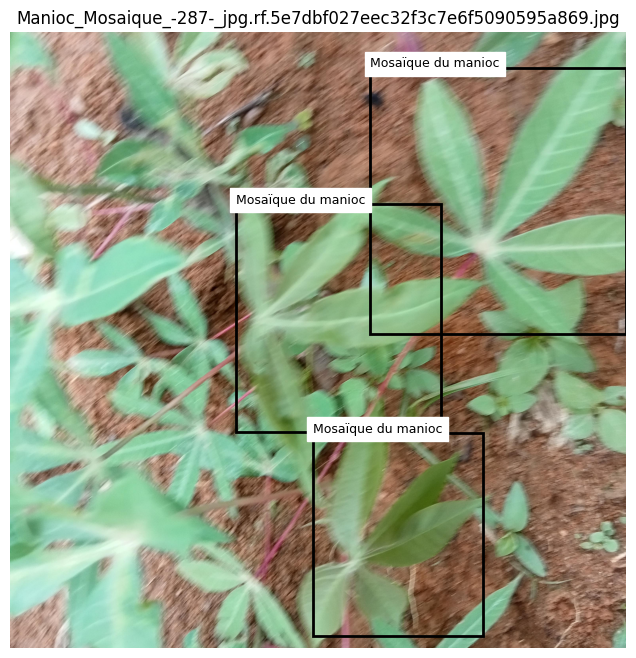

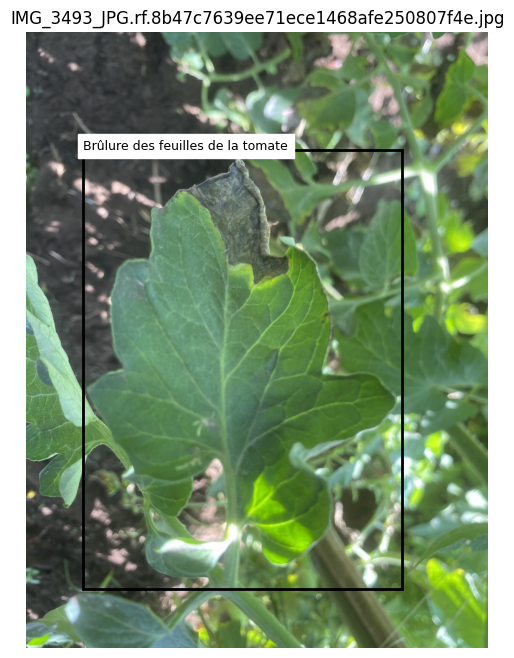

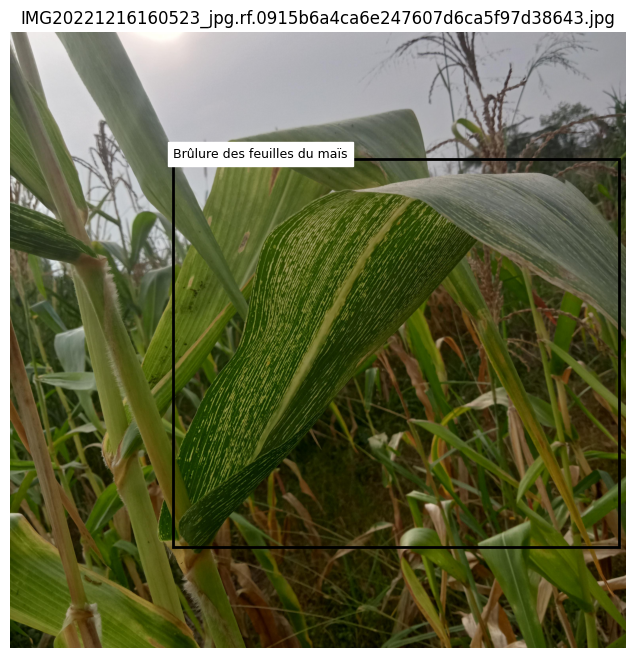

In [10]:
# ============================================================
# CELLULE 10 — VISUALISATION DES ANNOTATIONS YOLO
# ============================================================

def afficher_annotation(image_path, label_path):
    # Charger l'image
    image = Image.open(image_path).convert("RGB")
    
    # Dimensions de l'image
    largeur, hauteur = image.size

    # Conversion en tableau numpy
    image_np = np.array(image)

    # Affichage
    plt.figure(figsize=(10, 8))
    plt.imshow(image_np)

    # Lire les annotations
    with open(label_path, "r", encoding="utf-8") as f:
        lignes = f.readlines()

    for ligne in lignes:
        ligne = ligne.strip()

        if not ligne:
            continue

        class_id, x_center, y_center, width, height = map(
            float, ligne.split()
        )

        class_id = int(class_id)

        # Conversion YOLO → coordonnées pixels
        x_center *= largeur
        y_center *= hauteur
        width *= largeur
        height *= hauteur

        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2

        # Rectangle
        rectangle = plt.Rectangle(
            (x1, y1),
            width,
            height,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rectangle)

        # Nom de la classe
        class_name = data_config["names"][class_id]

        plt.text(
            x1,
            max(0, y1 - 5),
            class_name,
            fontsize=9,
            backgroundcolor="white"
        )

    plt.axis("off")
    plt.title(image_path.name)
    plt.show()


# ============================================================
# AFFICHER QUELQUES IMAGES
# ============================================================

images_train = list(TRAIN_IMAGES.glob("*"))

# Sélection de 3 images
random.seed(42)
images_selection = random.sample(images_train, min(3, len(images_train)))

for image_path in images_selection:

    label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

    if label_path.exists():
        afficher_annotation(image_path, label_path)

In [11]:
# ============================================================
# CELLULE 11 — VÉRIFICATION FINALE DU DATA.YAML
# ============================================================

print("VÉRIFICATION FINALE DE LA CONFIGURATION YOLO")
print("=" * 70)

# Nombre de classes
print(f"Nombre de classes : {data_config['nc']}")

# Chemins déclarés dans data.yaml
print(f"\nTrain      : {data_config['train']}")
print(f"Validation : {data_config['val']}")
print(f"Test       : {data_config['test']}")

# Vérification des dossiers
print("\nExistence des dossiers :")

assert TRAIN_IMAGES.exists(), "❌ Dossier train/images introuvable"
assert VALID_IMAGES.exists(), "❌ Dossier valid/images introuvable"
assert TEST_IMAGES.exists(), "❌ Dossier test/images introuvable"

print("✓ Train/images existe")
print("✓ Valid/images existe")
print("✓ Test/images existe")

# Vérification du nombre de classes
assert data_config["nc"] == 27
assert len(data_config["names"]) == 27

print("\n✓ 27 classes déclarées")
print("✓ 27 noms de classes présents")

# Vérification des images
assert len(train_set) == 3609
assert len(valid_set) == 773
assert len(test_set) == 774

print("\n✓ Train      : 3609 images")
print("✓ Validation : 773 images")
print("✓ Test       : 774 images")

print("\n" + "=" * 70)
print("✓ CONFIGURATION YOLO VALIDÉE")
print("✓ DATASET PRÊT POUR L'ENTRAÎNEMENT")

VÉRIFICATION FINALE DE LA CONFIGURATION YOLO
Nombre de classes : 27

Train      : train/images
Validation : valid/images
Test       : test/images

Existence des dossiers :
✓ Train/images existe
✓ Valid/images existe
✓ Test/images existe

✓ 27 classes déclarées
✓ 27 noms de classes présents

✓ Train      : 3609 images
✓ Validation : 773 images
✓ Test       : 774 images

✓ CONFIGURATION YOLO VALIDÉE
✓ DATASET PRÊT POUR L'ENTRAÎNEMENT


In [12]:
# ============================================================
# CELLULE 12 — VÉRIFICATION DU MATÉRIEL AVANT ENTRAÎNEMENT
# ============================================================

import torch

print("VÉRIFICATION DE L'ENVIRONNEMENT")
print("=" * 60)

print("Version PyTorch :", torch.__version__)

# Vérification GPU
if torch.cuda.is_available():
    print("✓ GPU CUDA disponible")
    print("GPU :", torch.cuda.get_device_name(0))
    print("Nombre de GPU :", torch.cuda.device_count())
else:
    print("⚠ Aucun GPU CUDA détecté")
    print("→ L'entraînement sera effectué sur le CPU.")

print("\nConfiguration YOLO :")
print("Nombre de classes :", data_config["nc"])
print("Images train      :", len(train_set))
print("Images validation :", len(valid_set))
print("Images test       :", len(test_set))

VÉRIFICATION DE L'ENVIRONNEMENT
Version PyTorch : 2.14.0+cpu
⚠ Aucun GPU CUDA détecté
→ L'entraînement sera effectué sur le CPU.

Configuration YOLO :
Nombre de classes : 27
Images train      : 3609
Images validation : 773
Images test       : 774


In [13]:
# ============================================================
# CELLULE 13 — ENTRAÎNEMENT YOLO : TEST
# ============================================================

from ultralytics import YOLO

# Charger le modèle
model = YOLO("yolo11n.pt")

print("✓ Modèle YOLO chargé")
print("Début de l'entraînement...")

✓ Modèle YOLO chargé
Début de l'entraînement...


In [14]:
# ============================================================
# CELLULE 14 — TESTE D'ENTRAÎNEMENT YOLO : TEST CPU
# ============================================================

results = model.train(
    data=str(DATA_YAML),
    epochs=3,
    imgsz=640,
    batch=4,
    device="cpu",
    workers=0,
    patience=2,
    project=str(PROJECT_ROOT / "runs"),
    name="fieldplant_test",
    seed=42
)

Ultralytics 8.4.148  Python-3.13.12 torch-2.14.0+cpu CPU (Intel Core i7-8650U 1.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\configs\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mos

In [ ]:
# ============================================================
# CELLULE 15 — ANALYSE DES RÉSULTATS D'ENTRAÎNEMENT
# ============================================================

RUN_DIR = PROJECT_ROOT / "runs" / "fieldplant_test-2"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Dossier d'entraînement :", RUN_DIR)
print("Fichier results.csv    :", RESULTS_CSV)

assert RESULTS_CSV.exists(), "       results.csv introuvable"

results_df = pd.read_csv(RESULTS_CSV)

print("\n✓ results.csv chargé avec succès")
print("Nombre d'époques :", len(results_df))

display(results_df)

Dossier d'entraînement : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\runs\fieldplant_test-2
Fichier results.csv    : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\runs\fieldplant_test-2\results.csv

✓ results.csv chargé avec succès
Nombre d'époques : 3


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,3405.84,1.17023,3.81032,1.56288,0.69164,0.16305,0.12205,0.09096,1.08026,3.10004,1.46661,0.000161,0.000161,0.000161
1,2,6477.06,1.11797,2.77719,1.51621,0.67323,0.18290,0.21304,0.15094,1.03428,2.54154,1.43357,0.000216,0.000216,0.000216
2,3,9548.65,1.06858,2.40668,1.47447,0.61766,0.22241,0.24088,0.17859,0.98981,2.32629,1.38883,0.000110,0.000110,0.000110


In [16]:
# ============================================================
# CELLULE 16 — MEILLEURE ÉPOQUE
# ============================================================

best_map50 = results_df["metrics/mAP50(B)"].max()
best_epoch = results_df.loc[
    results_df["metrics/mAP50(B)"].idxmax(),
    "epoch"
]

print("MEILLEUR RÉSULTAT")
print("=" * 50)
print(f"Meilleure époque : {int(best_epoch)}")
print(f"Meilleur mAP@50  : {best_map50:.4f}")

best_row = results_df.loc[
    results_df["metrics/mAP50(B)"].idxmax()
]

print(f"Precision        : {best_row['metrics/precision(B)']:.4f}")
print(f"Recall           : {best_row['metrics/recall(B)']:.4f}")
print(f"mAP@50           : {best_row['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95        : {best_row['metrics/mAP50-95(B)']:.4f}")

MEILLEUR RÉSULTAT
Meilleure époque : 3
Meilleur mAP@50  : 0.2409
Precision        : 0.6177
Recall           : 0.2224
mAP@50           : 0.2409
mAP@50-95        : 0.1786


Fichier : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\runs\fieldplant_test-2\results.png
Existe : True


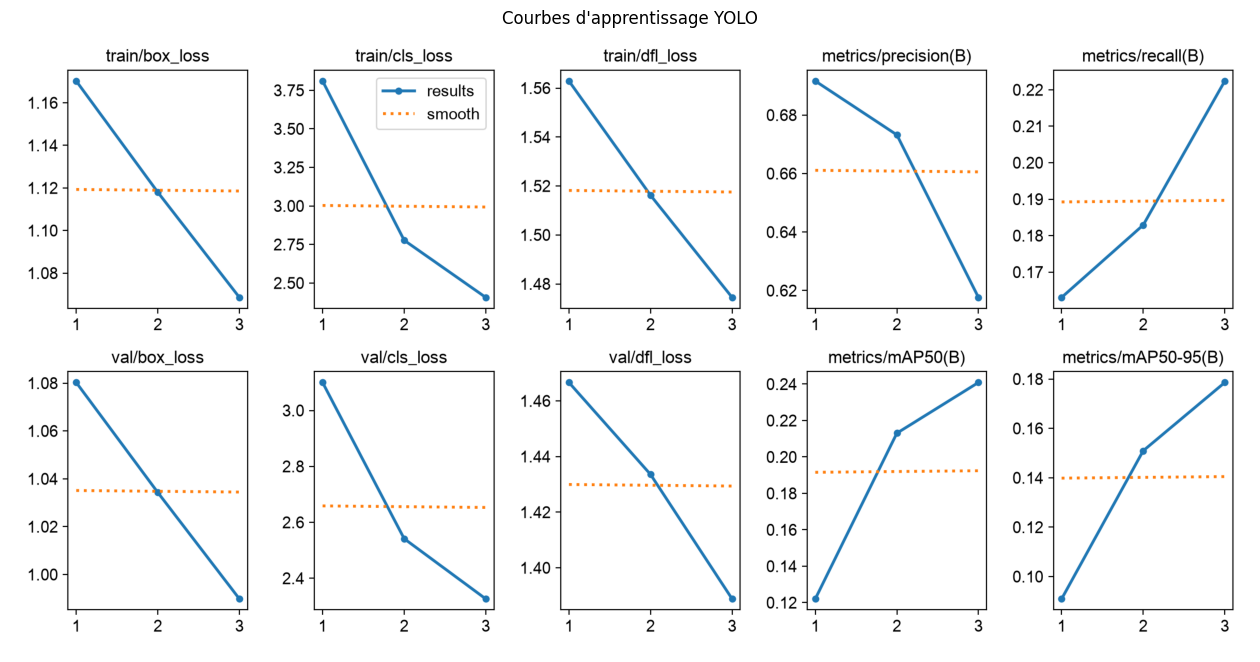

In [17]:
# ============================================================
# CELLULE 17 — COURBES D'APPRENTISSAGE
# ============================================================

RESULTS_PNG = RUN_DIR / "results.png"

print("Fichier :", RESULTS_PNG)
print("Existe :", RESULTS_PNG.exists())

if RESULTS_PNG.exists():
    image = Image.open(RESULTS_PNG)

    plt.figure(figsize=(16, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Courbes d'apprentissage YOLO")
    plt.show()
else:
    print("results.png introuvable")


Courbe Precision
--------------------------------------------------


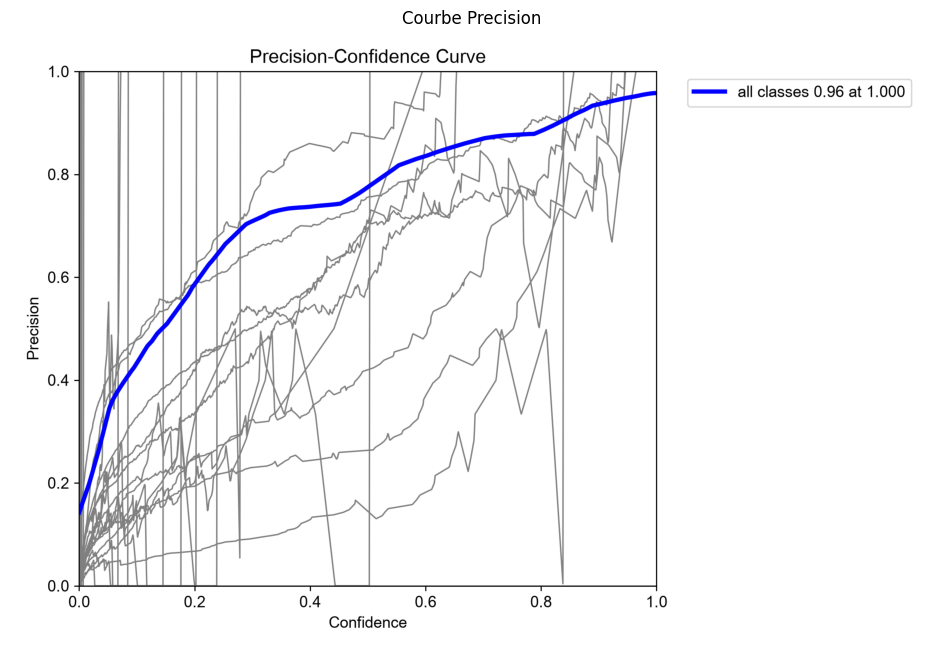


Courbe Recall
--------------------------------------------------


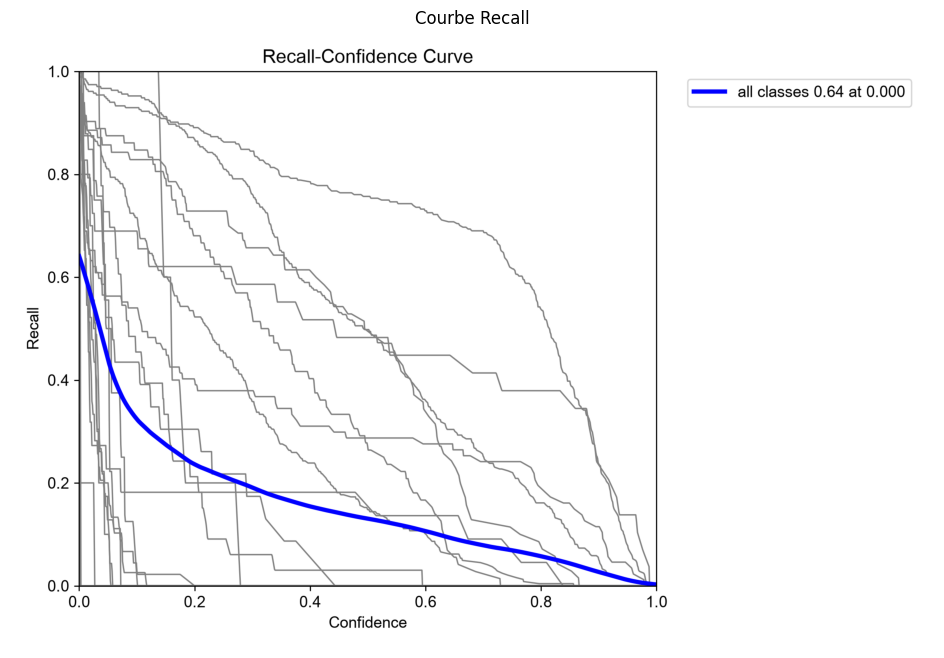


Courbe F1-score
--------------------------------------------------


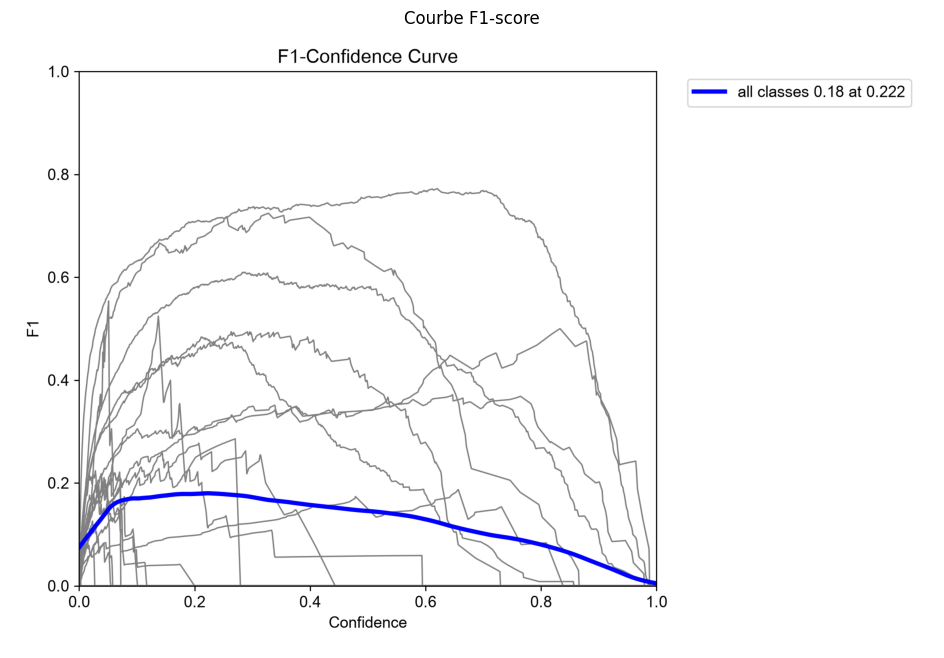


Courbe Precision-Recall
--------------------------------------------------


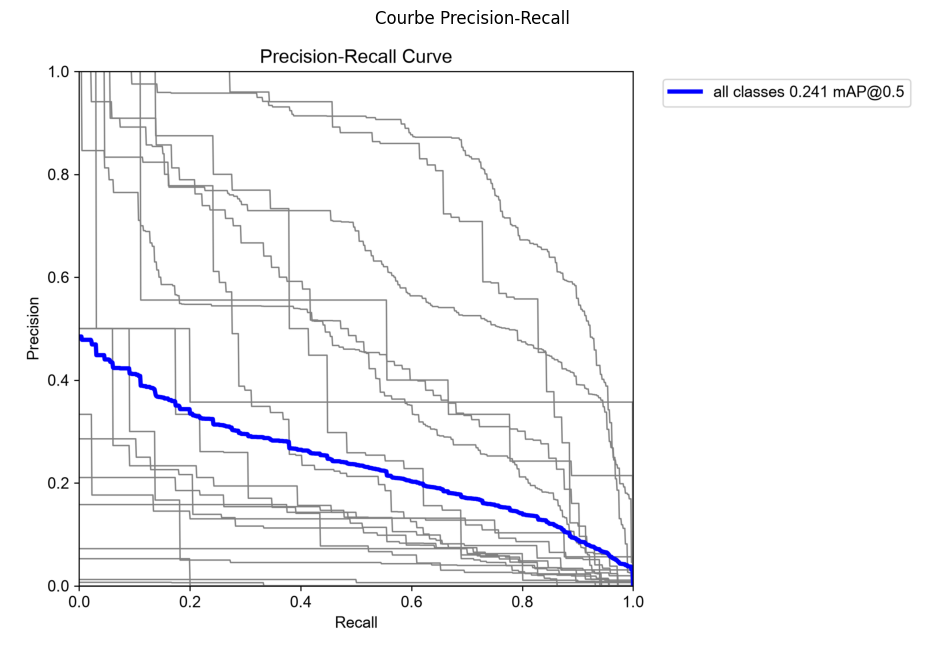

In [18]:
# ============================================================
# CELLULE 18 — COURBES PRECISION, RECALL, F1 ET PR
# ============================================================

courbes = [
    ("BoxP_curve.png", "Courbe Precision"),
    ("BoxR_curve.png", "Courbe Recall"),
    ("BoxF1_curve.png", "Courbe F1-score"),
    ("BoxPR_curve.png", "Courbe Precision-Recall")
]

for fichier, titre in courbes:
    chemin = RUN_DIR / fichier

    print(f"\n{titre}")
    print("-" * 50)

    if chemin.exists():
        image = Image.open(chemin)

        plt.figure(figsize=(12, 8))
        plt.imshow(image)
        plt.axis("off")
        plt.title(titre)
        plt.show()
    else:
        print(f" Fichier introuvable : {chemin}")

In [19]:
# ============================================================
# CELLULE 19 — ANALYSE DES CLASSES
# ============================================================

print("Nombre de classes :", len(data_config["names"]))

print("\nClasses du dataset :")
for class_id, class_name in data_config["names"].items():
    print(f"{class_id:2d} : {class_name}")

Nombre de classes : 27

Classes du dataset :
 0 : Flétrissement bactérien du manioc
 1 : Tache brune des feuilles du manioc
 2 : Manioc sain
 3 : Mosaïque du manioc
 4 : Pourriture des racines du manioc
 5 : Taches brunes du maïs
 6 : Charbon du maïs
 7 : Tache chlorotique des feuilles du maïs
 8 : Tache grise des feuilles du maïs
 9 : Maïs sain
10 : Dégâts d'insectes sur le maïs
11 : Mildiou du maïs
12 : Décoloration violette du maïs
13 : Charbon du maïs
14 : Stries du maïs
15 : Rayures du maïs
16 : Décoloration violette du maïs
17 : Taches jaunes du maïs
18 : Jaunissement du maïs
19 : Brûlure des feuilles du maïs
20 : Rouille des feuilles du maïs
21 : Taches brunes de la tomate
22 : Flétrissement bactérien de la tomate
23 : Brûlure des feuilles de la tomate
24 : Tomate saine
25 : Virus de la mosaïque des feuilles de tomate
26 : Virus du jaunissement des feuilles de tomate


In [20]:
# ============================================================
# CELLULE 20 — ENTRAÎNEMENT PRINCIPAL : 30 ÉPOQUES
# ============================================================

model = YOLO("yolo11n.pt")

results_main = model.train(
    data=str(DATA_YAML),
    epochs=30,
    imgsz=640,
    batch=4,
    device="cpu",
    workers=0,
    patience=8,
    project=str(PROJECT_ROOT / "runs"),
    name="fieldplant_30epochs",
    seed=42
)

print(" Entraînement principal terminé")

Ultralytics 8.4.148  Python-3.13.12 torch-2.14.0+cpu CPU (Intel Core i7-8650U 1.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\configs\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mo

In [21]:
# ============================================================
# CELLULE 21 — ANALYSE DE L'ENTRAÎNEMENT 30 ÉPOQUES
# ============================================================

RUN_DIR_MAIN = PROJECT_ROOT / "runs" / "fieldplant_30epochs"
RESULTS_CSV_MAIN = RUN_DIR_MAIN / "results.csv"

print("Dossier :", RUN_DIR_MAIN)
print("Fichier :", RESULTS_CSV_MAIN)
print("Existe :", RESULTS_CSV_MAIN.exists())

assert RESULTS_CSV_MAIN.exists(), "❌ results.csv introuvable"

results_main_df = pd.read_csv(RESULTS_CSV_MAIN)

print("\n✓ results.csv chargé")
print("Nombre d'époques enregistrées :", len(results_main_df))

display(results_main_df)

Dossier : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\runs\fieldplant_30epochs
Fichier : d:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\runs\fieldplant_30epochs\results.csv
Existe : True

✓ results.csv chargé
Nombre d'époques enregistrées : 30


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,7432.78,1.15378,3.89768,1.56032,0.69033,0.11795,0.09676,0.06737,1.04451,3.14681,1.44645,0.000108,0.000108,0.000108
1,2,12166.50,1.12629,2.82135,1.52094,0.70395,0.17103,0.17329,0.11850,1.05878,2.60538,1.43966,0.000208,0.000208,0.000208
2,3,17036.70,1.11261,2.41527,1.50301,0.49526,0.25405,0.21839,0.15035,1.06311,2.28942,1.44772,0.000302,0.000302,0.000302
3,4,22033.80,1.09819,2.23146,1.49000,0.53005,0.27131,0.26092,0.17943,1.11040,2.16172,1.46608,0.000291,0.000291,0.000291
4,5,27201.30,1.08913,2.09359,1.47246,0.58636,0.29320,0.30872,0.21725,1.04169,1.99304,1.40951,0.000280,0.000280,0.000280
5,6,32657.00,1.05122,1.98151,1.44057,0.53938,0.37264,0.35239,0.25690,1.02693,1.86190,1.40557,0.000270,0.000270,0.000270
6,7,37645.10,1.04439,1.89663,1.43251,0.47673,0.42429,0.37305,0.27508,1.00267,1.80350,1.35032,0.000259,0.000259,0.000259
7,8,42418.70,1.03968,1.82750,1.42564,0.42408,0.43454,0.36886,0.26944,0.97828,1.74131,1.34635,0.000248,0.000248,0.000248
8,9,45811.10,1.01045,1.74030,1.40232,0.59434,0.35768,0.37482,0.27587,0.99220,1.61686,1.35979,0.000238,0.000238,0.000238
9,10,49402.20,0.99990,1.69179,1.39071,0.56942,0.41184,0.41022,0.31170,0.93587,1.53337,1.30628,0.000227,0.000227,0.000227


In [22]:

# ============================================================
# CELLULE 22 — IDENTIFICATION DE LA MEILLEURE ÉPOQUE
# ============================================================

# Meilleure époque selon le mAP@50-95
idx_best = results_main_df["metrics/mAP50-95(B)"].idxmax()

best_epoch = int(results_main_df.loc[idx_best, "epoch"])
best_precision = results_main_df.loc[idx_best, "metrics/precision(B)"]
best_recall = results_main_df.loc[idx_best, "metrics/recall(B)"]
best_map50 = results_main_df.loc[idx_best, "metrics/mAP50(B)"]
best_map5095 = results_main_df.loc[idx_best, "metrics/mAP50-95(B)"]

print("MEILLEURE ÉPOQUE")
print("=" * 60)
print(f"Époque       : {best_epoch}")
print(f"Precision    : {best_precision:.4f}")
print(f"Recall       : {best_recall:.4f}")
print(f"mAP@50       : {best_map50:.4f}")
print(f"mAP@50-95    : {best_map5095:.4f}")

MEILLEURE ÉPOQUE
Époque       : 30
Precision    : 0.5477
Recall       : 0.5988
mAP@50       : 0.5968
mAP@50-95    : 0.4715


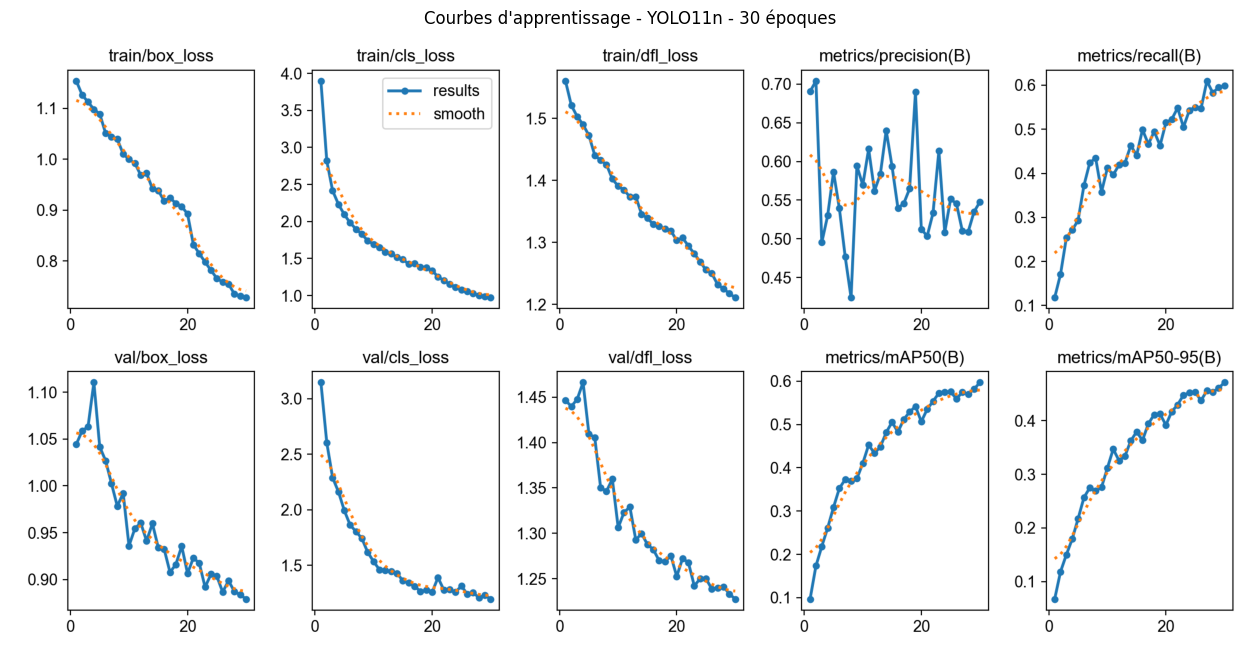

In [23]:
# ============================================================
# CELLULE 23 — COURBES D'APPRENTISSAGE DES 30 ÉPOQUES
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

RESULTS_PNG_MAIN = (
    PROJECT_ROOT
    / "runs"
    / "fieldplant_30epochs"
    / "results.png"
)

image = Image.open(RESULTS_PNG_MAIN)

plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis("off")
plt.title("Courbes d'apprentissage - YOLO11n - 30 époques")
plt.show()

In [24]:
# ============================================================
# CELLULE 24 — ÉVALUATION FINALE SUR LE JEU DE TEST
# ============================================================

from ultralytics import YOLO

# Charger le meilleur modèle sauvegardé
BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "runs"
    / "fieldplant_30epochs"
    / "weights"
    / "best.pt"
)

best_model = YOLO(str(BEST_MODEL_PATH))

# Évaluation sur le jeu TEST
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=4,
    device="cpu",
    workers=0,
    plots=True,
    project=str(PROJECT_ROOT / "runs"),
    name="fieldplant_test_evaluation"
)

print("Évaluation finale terminée.")

Ultralytics 8.4.148  Python-3.13.12 torch-2.14.0+cpu CPU (Intel Core i7-8650U 1.90GHz)
YOLO11n summary (fused): 100 layers, 2,587,417 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 300.223.1 MB/s, size: 1370.1 KB)
val: Scanning D:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant\test\labels... 774 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 774/774 689.1it/s 1.1s.0ss
val: New cache created: D:\cours DIT\semestre 2\computerVision\NOM_Prenom_ProjetCV_DetectionMaladiesFoliaires\data\fieldplant\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 194/194 1.1it/s 2:570.7ss
                   all        774       1353      0.493      0.592      0.559      0.436
Fltrissement bactrien du manioc          3          3      0.409      0.273      0.299      0.272
Tache brune des feuilles du manioc         23         24      0.478   